# EEG_11 — Windowed HGNN (W-HGNN)

**Evoluzione del ragionamento**:
- EEG_09: HGNN su feature full-trial (61,384) → chance. H statico, no temporalità.
- EEG_10: CNN temporale + HGNN → overfitting, peggio di EEG_09.
- EEG_11 v1: H_k = |PCC(x_k)| per finestra → rumoroso (47 df per 61² correlazioni).
- EEG_11 v2: H_k = H_pruned ⊙ |PCC(x_k)| → tautologico: H_pruned già basato su PCC.

**Approccio corretto**: la variazione temporale sta nei **nodi**, non nelle iperedge.
Usa H_pruned come topologia fissa (noise-free, consensus-validated) e processa il segnale
finestra per finestra — i feature dei nodi variano, la struttura resta stabile.

```
x (B,61,384) + H_pruned (B,61,61) [soft, non binarizzato]
  → split in K=8 finestre temporali
  per ogni finestra k (shared weights):
    feat_k = Linear(x_k)           — (B,61,32)  feature nodo variano per finestra
    out_k  = HGNNConv(feat_k, H_pruned).mean(dim=1)  — (B,hidden)  topologia fissa
  z = mean(out_1..K) → Linear → logits (B,4)
```

**Differenza da EEG_09**: EEG_09 dava tutti i 384 sample in input direttamente.
W-HGNN divide in K=8 finestre da 48 sample e le processa separatamente — la rete
impara pattern locali (onset, picchi di sincronizzazione) invece di feature aggregate.

Ablation: 5 metriche pruned = 5 run. Split: TRAIN 0-49, VAL 50-59, TEST 60-73.

In [ ]:
import json, logging, re, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg11')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / '.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)

# ---- CONFIG ----
N_CHANNELS     = 61
N_SAMPLES      = 384
N_CLASSES      = 4
CLUSTER_SCHEME = 'concr4'

SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

# Dynamic HGNN
K_WINDOWS  = 8      # finestre temporali (384/8 = 48 sample = ~188ms a 256Hz)
D_NODE     = 16     # embedding per nodo per finestra (Linear 48->32)
HIDDEN     = 64
N_LAYERS   = 1
DROPOUT    = 0.6    # alzato da 0.3

# Training
LR             = 1e-3
WEIGHT_DECAY   = 5e-3   # alzato da 1e-4
GRAD_CLIP      = 1.0
BATCH_SIZE     = 64
MAX_EPOCHS     = 60
PATIENCE       = 7
USE_INSTANCE_NORM = True
LABEL_SMOOTHING   = 0.1

# Data augmentation — solo su training set
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

METRICS   = ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']
LOAD_DIR  = 'hypergraphs_pruned'

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root / 'configs' / 'label_schemes' / 'labelid2cluster_concr4.json').read_text()).items()}

T_WIN = N_SAMPLES // K_WINDOWS
log.info(f'K_WINDOWS={K_WINDOWS}  T_WIN={T_WIN}  D_NODE={D_NODE}  HIDDEN={HIDDEN}')
log.info(f'SUBJ TRAIN={len(SUBJ_TRAIN)} VAL={len(SUBJ_VAL)} TEST={len(SUBJ_TEST)}')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  GRAD_CLIP={GRAD_CLIP}  USE_AUG={USE_AUGMENTATION}')

## §2 — Dataset (carica x e H_pruned; H_k calcolato per finestra nel modello)

In [ ]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class EEGWindowDataset(Dataset):
    """
    Carica x (61,384), H_pruned (61,61) e y dai file .pt di EEG_07f.
    H_pruned usato SOFT (valori continui, non binarizzato) — topologia fissa.
    """
    def __init__(self, subj_ids, metric, use_instance_norm=True, augment=False):
        root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
        self.paths, self.labels = [], []
        self.use_instance_norm = use_instance_norm
        self.augment = augment
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            if int(m.group(1)) not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is None: continue
            self.paths.append(p)
            self.labels.append(c)
        log.info(f'  hypergraphs_pruned_{metric}: {len(self.paths)} trial')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()   # (61, 384)
        H = d['H'].float()   # (61, E)

        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)

        if H.shape[1] < N_CHANNELS:
            H = F.pad(H, (0, N_CHANNELS - H.shape[1]))
        elif H.shape[1] > N_CHANNELS:
            H = H[:, :N_CHANNELS]

        return x, H, torch.tensor(self.labels[idx], dtype=torch.long)


def make_loaders(metric):
    tr = EEGWindowDataset(SUBJ_TRAIN, metric, USE_INSTANCE_NORM, augment=USE_AUGMENTATION)
    va = EEGWindowDataset(SUBJ_VAL,   metric, USE_INSTANCE_NORM, augment=False)
    te = EEGWindowDataset(SUBJ_TEST,  metric, USE_INSTANCE_NORM, augment=False)
    kw = dict(num_workers=2, pin_memory=True)
    labels   = np.array(tr.labels)
    counts   = np.bincount(labels, minlength=N_CLASSES)
    sample_w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw))

## §3 — Modello: W-HGNN (Windowed HGNN)

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019)"""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) soft
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class WindowedHGNN(nn.Module):
    """
    W-HGNN: topologia H_pruned FISSA per tutte le finestre.
    I feature dei nodi variano per finestra — la rete impara pattern temporali locali.

    Per ogni finestra k (pesi condivisi):
      feat_k = Linear(x_k)            — (B,N,d_node)  feature variano
      out_k  = HGNN(feat_k, H_pruned) — H FISSO, stessa topologia per tutti i k
    z = mean(out_1..K) → clf
    """
    def __init__(self, T_win=T_WIN, K=K_WINDOWS, d_node=D_NODE,
                 hidden=HIDDEN, n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win = K, T_win
        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_node),
            nn.LayerNorm(d_node),
            nn.ELU(),
        )
        dims = [d_node] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def forward(self, x, H):
        # x: (B,N,T)  H: (B,N,N) soft — FISSA per tutte le finestre
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win) — varia
            feat = self.node_proj(x_k)                        # (B,N,d_node) — varia
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H)                            # H invariato per ogni k
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))                      # (B,hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


# Sanity check
_m  = WindowedHGNN()
_x  = torch.randn(4, N_CHANNELS, N_SAMPLES)
_H  = torch.rand(4, N_CHANNELS, N_CHANNELS)   # soft H_pruned
assert _m(_x, _H).shape == (4, N_CLASSES)
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'WindowedHGNN OK — {n_p:,} parametri  K={K_WINDOWS} finestre x {T_WIN} sample')
del _m, _x, _H


11:44:34 INFO     WindowedHGNN OK — 23,396 parametri  K=8 finestre x 48 sample


## §4 — Train / Eval

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')

_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, H, y in loader:
            x, H, y = x.to(device), H.to(device), y.to(device)
            logits = model(x, H)
            loss   = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_model(run_name, tr_loader, va_loader, te_loader, config):
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=config, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))
    model = WindowedHGNN().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_bacc, _, _ = run_epoch(model, tr_loader, opt)
        va_loss, va_bacc, _, _ = run_epoch(model, va_loader)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_bacc,
                 'val/loss': va_loss,   'val/bacc': va_bacc,
                 'train_val_gap': tr_bacc - va_bacc,
                 'epoch': epoch})
        if va_bacc > best_val:
            best_val = va_bacc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  early stop epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, te_bacc, te_labels, te_preds = run_epoch(model, te_loader)
    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_bacc
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_preds.tolist(), y_true=te_labels.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  {run_name}: val={best_val:.4f} test={te_bacc:.4f}')
    return best_val, te_bacc, te_labels, te_preds

## §5 — Ablation Loop (5 metriche)

In [5]:
RESULTS = {}

for metric in METRICS:
    name = f'eeg11_WHGNN_{metric}_{CLUSTER_SCHEME}'
    log.info(f'\n=== {name} ===')
    try:
        tr_l, va_l, te_l = make_loaders(metric)
    except Exception as e:
        log.warning(f'  Skip {metric}: {e}'); continue

    cfg = dict(
        notebook='EEG_11', model='WindowedHGNN', metric=metric,
        n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, t_win=T_WIN, d_node=D_NODE,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        weighted_sampler=True,
        topology='H_pruned_soft_fixed',
        temporal_dynamics='node_features_per_window',
        n_train_subj=len(SUBJ_TRAIN),
    )
    val_b, test_b, lbl, pred = train_model(name, tr_l, va_l, te_l, cfg)
    RESULTS[metric] = {'val': val_b, 'test': test_b}

log.info('\n=== ABLATION DONE ===')
for k, v in RESULTS.items():
    print(f'  {k:15s}  val={v["val"]:.4f}  test={v["test"]:.4f}')


11:44:34 INFO     
=== eeg11_WHGNN_pcc_concr4 ===
11:44:46 INFO       hypergraphs_pruned_pcc: 26123 trial
11:44:49 INFO       hypergraphs_pruned_pcc: 5500 trial
11:44:55 INFO       hypergraphs_pruned_pcc: 7260 trial
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


11:47:03 INFO       early stop epoch 17


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
train/bacc,▁▂▂▂▂▃▄▄▄▅▆▆▅▇▇▇█
train/loss,█▇▇▇▆▆▅▅▅▄▃▃▃▂▂▂▁
val/bacc,▅▇▄▄█▂▆▅▅▄▁▅▅▃▇▅▃
val/loss,▄▄▄▄▅▂▅▄▇▁▇▅▄▃▃█▆
epoch,17
test_bacc,0.24907
train/bacc,0.31563
train/loss,1.36862
val/bacc,0.24722
val/loss,1.40621


11:47:08 INFO       eeg11_WHGNN_pcc_concr4: val=0.2555 test=0.2491
11:47:08 INFO     
=== eeg11_WHGNN_abs_pcc_concr4 ===
11:47:28 INFO       hypergraphs_pruned_abs_pcc: 26123 trial
11:47:32 INFO       hypergraphs_pruned_abs_pcc: 5500 trial
11:47:37 INFO       hypergraphs_pruned_abs_pcc: 7260 trial


11:50:44 INFO       early stop epoch 24


...

11:58:40 INFO       eeg11_WHGNN_wpli_concr4: val=0.2599 test=0.2520
11:58:40 INFO     
=== eeg11_WHGNN_plv_concr4 ===
11:59:00 INFO       hypergraphs_pruned_plv: 26123 trial
11:59:04 INFO       hypergraphs_pruned_plv: 5500 trial
11:59:10 INFO       hypergraphs_pruned_plv: 7260 trial


12:02:36 INFO       early stop epoch 27


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train/bacc,▁▁▁▂▂▂▃▄▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇███
train/loss,█▇▇▇▇▇▆▆▆▆▆▆▅▅▄▄▄▄▄▃▃▃▂▂▁▁▁
val/bacc,▅▅▄█▁▅▄▄▅█▆▆▅██▂▅▄▅▄▄▇▄▆▇▄▆
val/loss,▃▃▁█▂▃▃▂▄▃▄▅▆▃▅▃▃▂▄▅▆█▇▄▄▃▆
epoch,27
test_bacc,0.25321
train/bacc,0.33368
train/loss,1.35372
val/bacc,0.2567
val/loss,1.42075


12:02:41 INFO       eeg11_WHGNN_plv_concr4: val=0.2613 test=0.2532
12:02:41 INFO     
=== ABLATION DONE ===


  pcc              val=0.2555  test=0.2491
  abs_pcc          val=0.2534  test=0.2597
  im_pcc           val=0.2616  test=0.2611
  wpli             val=0.2599  test=0.2520
  plv              val=0.2613  test=0.2532


## §6 — Risultati + Confronto EEG_09 / EEG_10

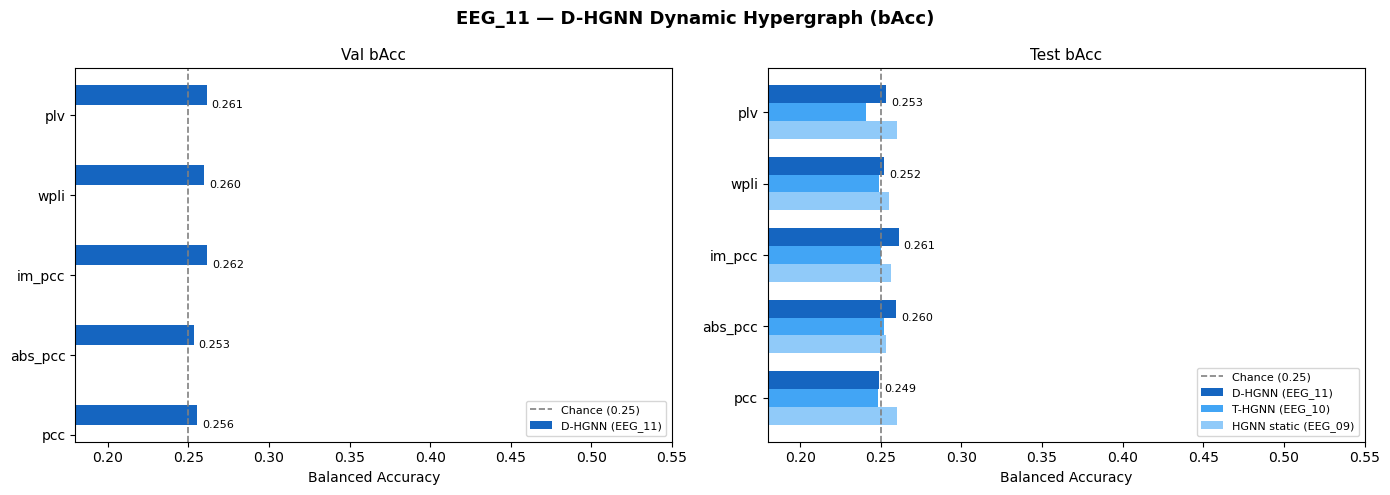


--- Test bAcc: D-HGNN vs baseline ---
 metric  eeg09  eeg10    eeg11  delta_vs_09
    pcc  0.260  0.248 0.249065      -0.0109
abs_pcc  0.253  0.252 0.259651       0.0067
 im_pcc  0.256  0.250 0.261144       0.0051
   wpli  0.255  0.249 0.251993      -0.0030
    plv  0.260  0.241 0.253214      -0.0068


In [6]:
EEG09 = {'pcc': 0.260, 'abs_pcc': 0.253, 'im_pcc': 0.256, 'wpli': 0.255, 'plv': 0.260}
EEG10 = {'pcc': 0.248, 'abs_pcc': 0.252, 'im_pcc': 0.250, 'wpli': 0.249, 'plv': 0.241}

if RESULTS:
    chance = 1 / N_CLASSES
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('EEG_11 — D-HGNN Dynamic Hypergraph (bAcc)', fontsize=13, fontweight='bold')

    for ax, split in zip(axes, ['val', 'test']):
        v11 = [RESULTS.get(m, {}).get(split, np.nan) for m in METRICS]
        y_pos = np.arange(len(METRICS))
        h = 0.25
        ax.barh(y_pos + h, v11, height=h, label='D-HGNN (EEG_11)', color='#1565C0')
        if split == 'test':
            v10 = [EEG10.get(m, np.nan) for m in METRICS]
            v09 = [EEG09.get(m, np.nan) for m in METRICS]
            ax.barh(y_pos,     v10, height=h, label='T-HGNN (EEG_10)',      color='#42A5F5')
            ax.barh(y_pos - h, v09, height=h, label='HGNN static (EEG_09)', color='#90CAF9')
        ax.axvline(chance, color='gray', linestyle='--', linewidth=1.2, label=f'Chance ({chance:.2f})')
        ax.set_yticks(y_pos); ax.set_yticklabels(METRICS, fontsize=10)
        ax.set_xlim(0.18, max(0.55, max([v for v in v11 if not np.isnan(v)] or [0.55]) + 0.06))
        ax.set_xlabel('Balanced Accuracy')
        ax.set_title(f'{split.capitalize()} bAcc', fontsize=11)
        ax.legend(fontsize=8, loc='lower right')
        for i, v in enumerate(v11):
            if not np.isnan(v):
                ax.text(v + 0.003, y_pos[i] + h/2, f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg11_dhgnn_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n--- Test bAcc: D-HGNN vs baseline ---')
    rows = []
    for m in METRICS:
        v11t = RESULTS.get(m, {}).get('test', np.nan)
        rows.append({'metric': m,
                     'eeg09': EEG09.get(m, np.nan),
                     'eeg10': EEG10.get(m, np.nan),
                     'eeg11': v11t,
                     'delta_vs_09': round(v11t - EEG09.get(m, np.nan), 4) if not np.isnan(v11t) else np.nan})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    df.to_csv(FIG_DIR / 'eeg11_dhgnn_results.csv', index=False)
